# `Machine Learning project (group SEA, 13) -  Alkemy AI Productivity`
### **What happens to margins when AI enters business workflows?**

## Import of the libraries 

In [35]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import missingno as msno
from IPython.display import display, Markdown
from itertools import zip_longest
import warnings

In [36]:
warnings.filterwarnings('ignore')

## Upload of the dataset

In [37]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [38]:
df_productivity = pd.read_csv(PATH)

## `First EDA`

In [39]:
print("Dataset shape:", df_productivity.shape)

Dataset shape: (3248, 34)


In [40]:
df_productivity["scope_change_flag"].unique()

array([0, 1])

In [41]:
print("--- INFO ---")
df_productivity.info()

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sl

In [42]:
num_cols = df_productivity.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_productivity.select_dtypes(include=['object', 'string']).columns.tolist()
bool_cols = df_productivity.select_dtypes(include=['bool', 'boolean']).columns.tolist()

# Create a Markdown table layout
md_text = f"""
| 🔢 Numerical ({len(num_cols)}) | 🔠 Categorical ({len(cat_cols)}) | 🔘 Boolean ({len(bool_cols)}) |
| :--- | :--- | :--- |
"""

# Zip all THREE lists together
for num, cat, b_col in zip_longest(num_cols, cat_cols, bool_cols, fillvalue=""):
    md_text += f"| {num} | {cat} | {b_col} |\n"

# Display the table
print("Columns Types:")
display(Markdown(md_text))

Columns Types:



| 🔢 Numerical (15) | 🔠 Categorical (18) | 🔘 Boolean (1) |
| :--- | :--- | :--- |
| task_complexity_score | task_id | ai_assisted |
| brief_quality_score | client |  |
| scope_change_flag | project_id |  |
| sla_days | client_tier |  |
| sla_breach | team |  |
| hours_spent | task_type |  |
| billable_hours | seniority |  |
| ai_usage_pct | deadline_pressure |  |
| revisions | pricing_model |  |
| errors | created_at |  |
| rework_hours | delivered_at |  |
| outcome_score | created_by |  |
| revenue | updated_at |  |
| cost | task_status |  |
| profit | workflow_stage |  |
|  | jira_ticket |  |
|  | legacy_ai_flag |  |
|  | content_version |  |


In [43]:
print("--- DESCRIPTIVE STATISTICS  ---")
df_productivity.describe()

--- DESCRIPTIVE STATISTICS  ---


,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


### Dataset Overview and Descriptive Statistics
The dataset contains **3,248 observations** and **34 variables**, each observation representing a single task performed within a business workflow. The unit of analysis is at the task level, enabling a granular assessment of operational performance.
#### Data Types
Based on the info and exploratory steps executed, the 34 columns are categorized as follows:
- **15 Numerical variables** (e.g., `task_complexity_score`, `hours_spent`, `revenue`, `profit`)
- **18 Categorical variables** (e.g., `task_id`, `client`, `seniority`, `task_type`)
- **1 Boolean variable** (`ai_assisted`)                    

The variables encompass multiple dimensions of the workflow:
- **Operational efficiency**: `hours_spent` (mean: 13.06, max: 263.6), `billable_hours`, `sla_days` (mean: 5.01)
- **AI adoption**: `ai_usage_pct` (ranging from 0% to 93%), `ai_assisted`
- **Quality and process performance**: `revisions` (mean: 3.0), `errors` (mean: 1.01, max: 7), `rework_hours` (mean: 2.44, max: 57.5)
- **Economic outcomes**: `revenue` (mean: 1,120), `cost` (mean: 771), `profit`
---
### Descriptive Statistics Highlights
The summary statistics provide initial insights into the distribution and variability of key variables:
#### 1) Profit and Economic Outcomes
The average **profit** is approximately 349, while the median is lower (around 255), indicating a right-skewed distribution. The presence of strongly negative values (minimum ≈ -8510) suggests that some tasks generate substantial losses, while others are highly lucrative (maximum ≈ 14006). A high standard deviation (≈ 888) reflects significant variability in profitability across tasks. Similarly, **revenue** is heavily right-skewed with a maximum of nearly 15,000 compared to a mean of 1,120.
#### 2) AI Usage
The average **AI usage** is approximately 36% (`ai_usage_pct`), missing in some records, with existing values ranging strictly from 0% to 93%. This continuous spectrum indicates that AI is not uniformly adopted across tasks but varies significantly in intensity. This enables the analysis of non-linear relationships and the identification of potential threshold effects.
#### 3) Time and Efficiency
The average **time spent** per task is roughly 13 hours, with a median of about 11 hours. Extreme outliers are present (maximum ≈ 263 hours), suggesting the existence of highly complex or delayed tasks. In addition, ~40% of the recorded tasks incurred an **SLA breach** (mean `sla_breach`: 0.398).
#### 4) Rework and Quality Performance
The average **rework time** is approximately 2.4 hours, but severely right-skewed with a maximum value exceeding 57 hours. This suggests that a small subset of tasks generates disproportionately high levels of rework, severely impacting efficiency. Task complexity scores and brief quality scores both hover around a mean of 3 on a 1-5 scale, indicating moderate difficulty and baseline quality on average.

---
### Data Quality Considerations
Several variables contain missing values. In 3,248 total rows, columns like `ai_usage_pct` (3,104 non-null), `rework_hours` (3,176 non-null), `billable_hours` (3,166 non-null), `outcome_score` (3,115 non-null), and `brief_quality_score` (3,179 non-null) show gaps. Rather than being solely technical issues, these missing entries may reflect real-world data collection limitations, unrecorded workflows, or process inefficiencies requiring careful imputation.

---
### Implications for Further Analysis
This descriptive phase highlights the following key directions:
1. **Heterogeneous Profitability**: The extreme variability in profit and rework hours motivates investigating exactly which conditions (e.g., `client_tier`, `task_type`) lead to losses versus high margins.
2. **AI Impact on Efficiency**: AI usage is recorded as a continuous percentage, allowing for deeply exploring its linear or non-linear effects on completion time (`hours_spent`) and quality (`errors`, `rework_hours`).
3. **Quality Instability**: Rework and SLA breaches are concentrated in specific tasks, representing clear points of leverage for process optimization.

#### Variables' Distribution

#### 1) Numerical variables:

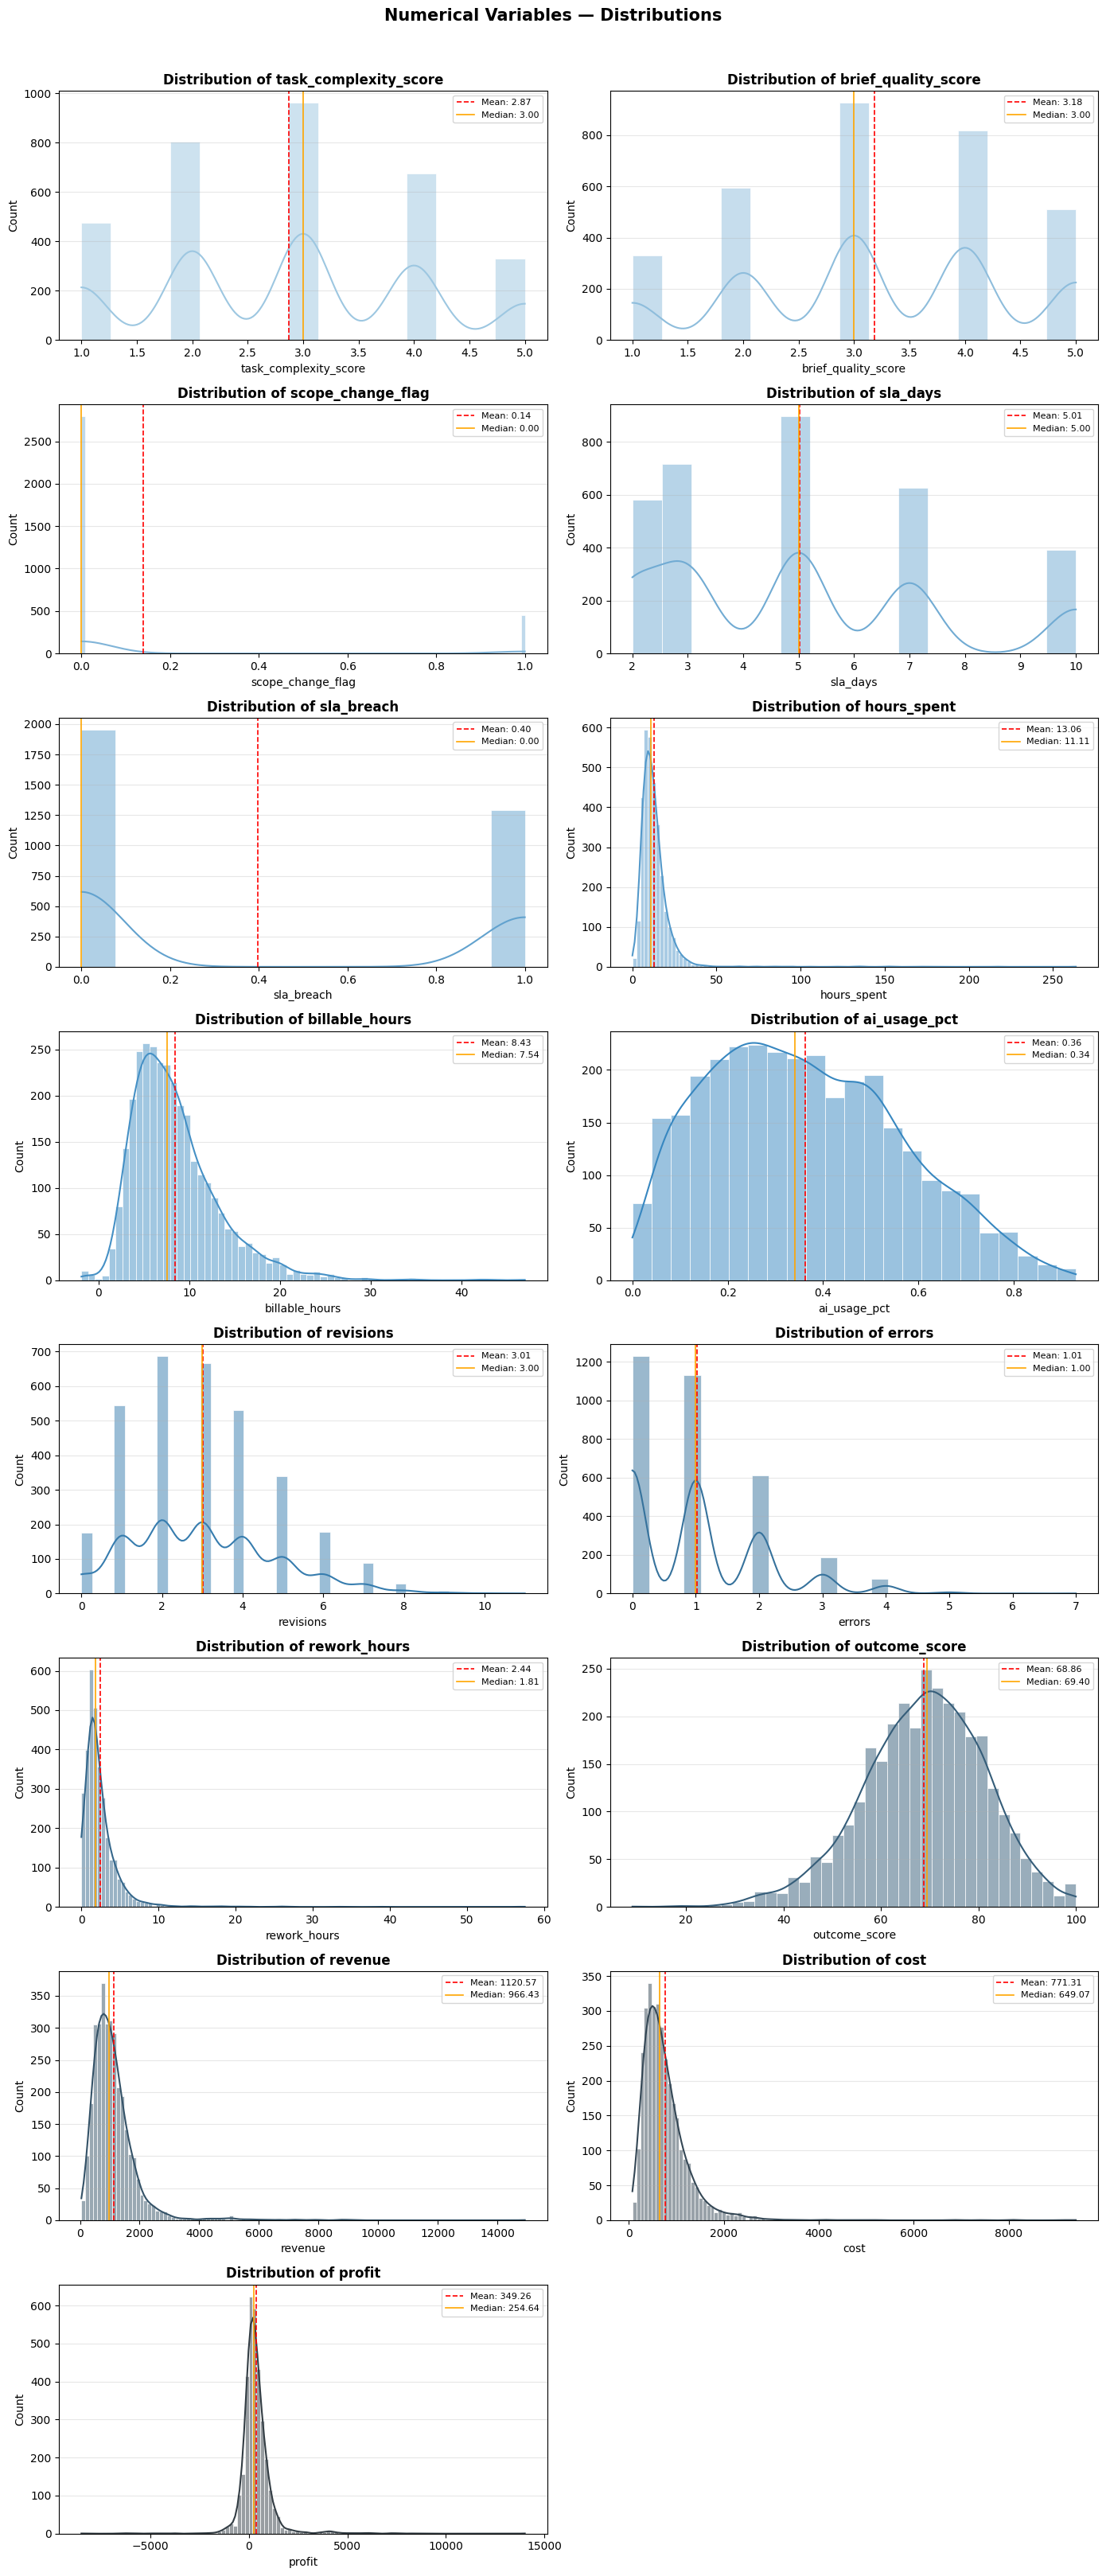

In [44]:
n_cols = 2
n_rows = (len(num_cols) + 1) // 2 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

palette = sns.color_palette("Blues_d", len(num_cols))  # Gradient palette

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    sns.histplot(
        df_productivity[col],
        kde=True,
        color=palette[i],
        ax=ax,
        edgecolor='white',
        linewidth=0.5
    )
    
    # Vertical lines for mean and median
    mean_val = df_productivity[col].mean()
    median_val = df_productivity[col].median()
    ax.axvline(mean_val,   color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle='-',  linewidth=1.2, label=f'Median: {median_val:.2f}')
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Hide any unused axes (when len(num_cols) is odd)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Variables — Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()


#### 2) Categorical & Boolean Variables

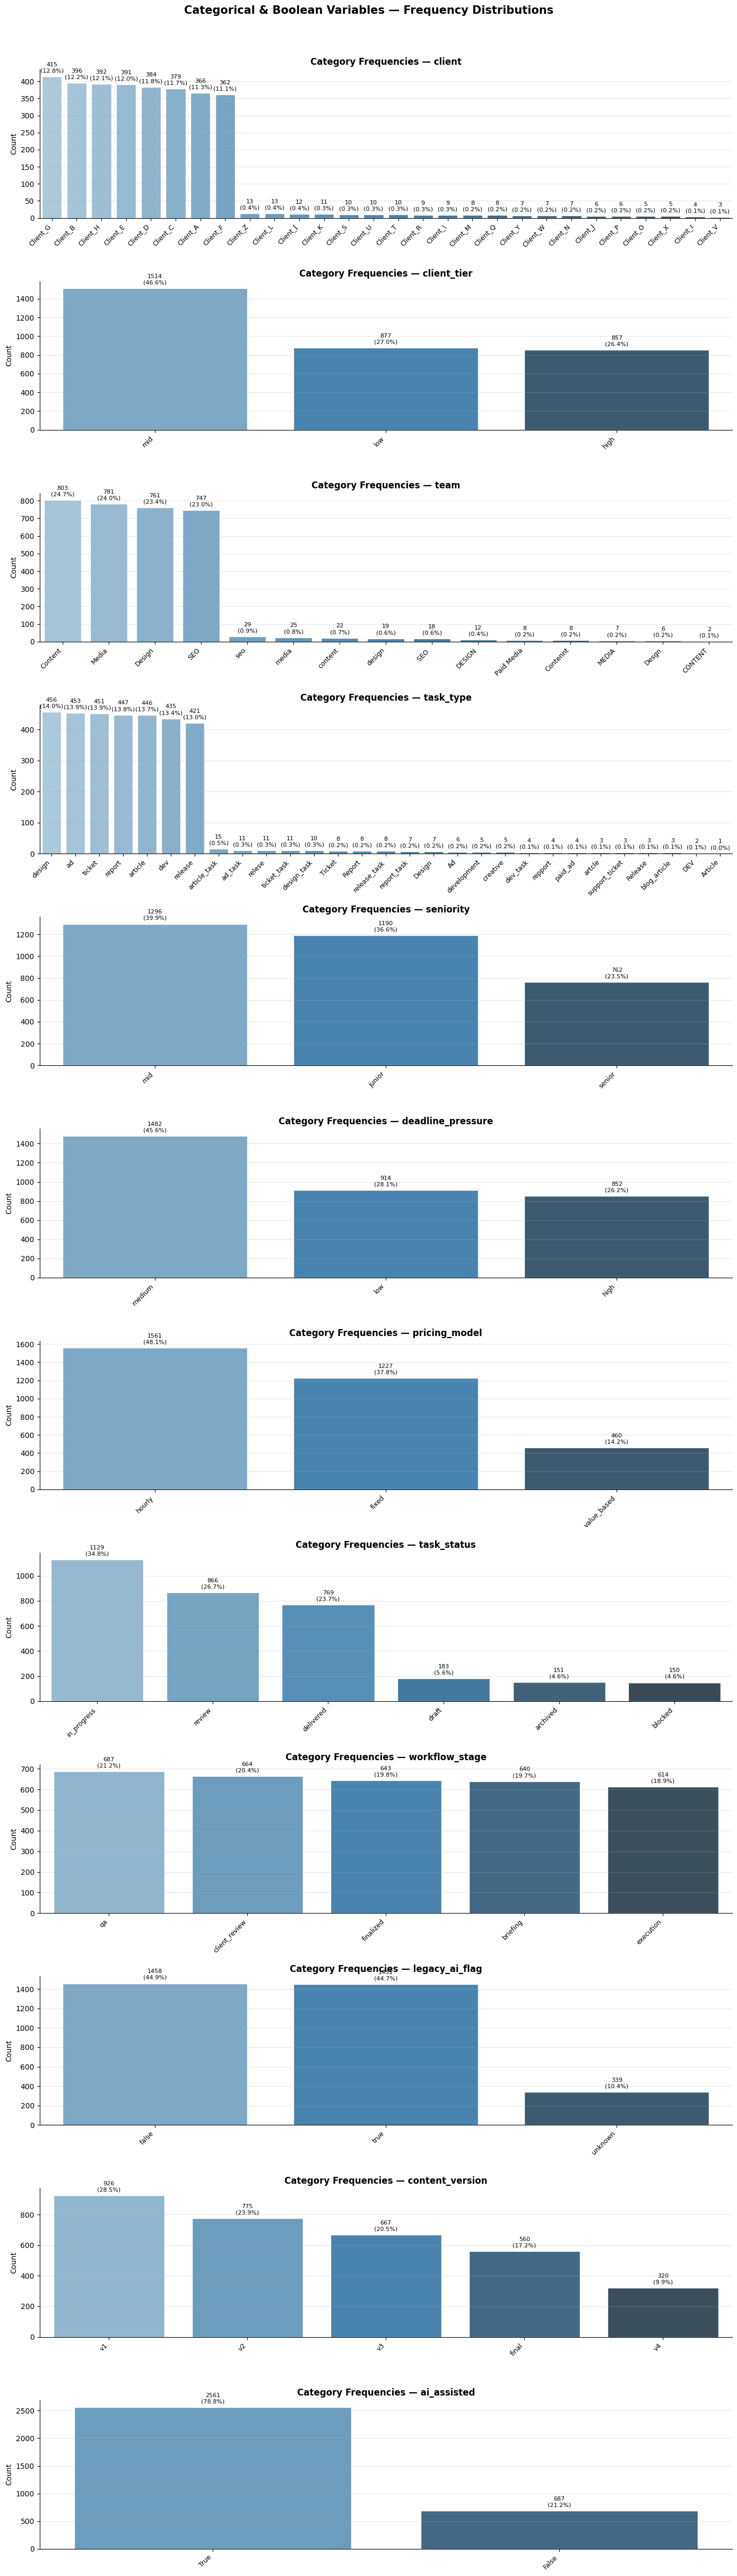

In [45]:
exclude_categories = ["task_id", "project_id", "created_at", "delivered_at", "created_by", "updated_at", "jira_ticket"]
cat_cols_filtered = [col for col in cat_cols if col not in exclude_categories]

cols_to_plot = cat_cols_filtered + bool_cols

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(14, 4 * len(cols_to_plot)))
sns.despine()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    # Build counts
    counts = (
        df_productivity[col]
        .value_counts(dropna=True)          
        .reset_index()
    )

    # Plot as barplot 
    sns.barplot(
        data=counts,
        x=col,
        y='count',
        palette='Blues_d',
        order=counts[col],          # Sorted by frequency (value_counts output)
        ax=ax,
        edgecolor='white',
    )

    # Annotate each bar with count + percentage
    total = counts['count'].sum()
    for bar in ax.patches:
        height = bar.get_height()
        pct = height / total * 100
        ax.annotate(
            f'{int(height)}\n({pct:.1f}%)',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8
        )

    ax.set_title(f'Category Frequencies — {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticklabels(ax.get_xticklabels(), ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Hide any trailing empty axes 
for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical & Boolean Variables — Frequency Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()


### Duplicates Check

In [46]:
duplicates = df_productivity.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [47]:
dup_count = df_productivity.duplicated(subset='task_id').sum()
print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 48


In [48]:
df_productivity['updated_at'] = pd.to_datetime(df_productivity['updated_at'])

df_productivity = (
    df_productivity
    .sort_values(['task_id', 'updated_at'])
    .groupby('task_id')
    .tail(1)
    .reset_index(drop=True)
)

In [49]:
dup_count = df_productivity.duplicated(subset='task_id').sum()
print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 0


#### Normalization of the "team" column

In [50]:
df_productivity['team'] = df_productivity['team'].str.strip()

print('Teams BEFORE:', sorted(df_productivity['team'].dropna().unique()))

df_productivity['team'] = df_productivity['team'].str.lower()

team_map = {
    'seo': 'SEO',
    'media': 'Media',
    'paid media': 'Media',
    'content': 'Content',
    'contennt': 'Content',
    'design': 'Design',
    'desgn': 'Design'
}

df_productivity['team'] = df_productivity['team'].replace(team_map)
print('Teams AFTER:', sorted(df_productivity['team'].dropna().unique()))

Teams BEFORE: ['CONTENT', 'Contennt', 'Content', 'DESIGN', 'Desgn', 'Design', 'MEDIA', 'Media', 'Paid Media', 'SEO', 'content', 'design', 'media', 'seo']
Teams AFTER: ['Content', 'Design', 'Media', 'SEO']


In [51]:
print('\nDistribution:')
display(df_productivity['team'].value_counts(dropna=False).to_frame())


Distribution:


,count
team,
Content,827
Media,805
Design,790
SEO,778


#### Date Parsing

In [52]:
date_cols = ['created_at', 'delivered_at']
for col in date_cols:
    df_productivity[col] = pd.to_datetime(df_productivity[col], errors='coerce')
    n_nat = df_productivity[col].isna().sum()
    print(f"{col}: {n_nat} values NaT after the conversion")

# Creation of the column "duration_days"
df_productivity['duration_days'] = (
    df_productivity['delivered_at'] - df_productivity['created_at']
).dt.days

# Dealing with negative values of the "duration_days" column
mask_neg = df_productivity['duration_days'] < 0
neg_count = mask_neg.sum()
print(f"\nNegative durations found: {neg_count}")

print("\n-------")
print("Snapshot of the negative 'duration days' values:")

if neg_count > 0:
    print(f"\n{df_productivity.loc[mask_neg, ['task_id', 'created_at', 'delivered_at', 'duration_days']].head()}")
    df_productivity.loc[mask_neg, 'duration_days'] = np.nan

created_at: 0 values NaT after the conversion
delivered_at: 38 values NaT after the conversion

Negative durations found: 14

-------
Snapshot of the negative 'duration days' values:

     task_id created_at delivered_at  duration_days
89    T00089 2025-10-06   2025-10-05           -1.0
403   T00403 2026-02-09   2026-02-08           -1.0
878   T00878 2026-03-29   2026-03-26           -3.0
1083  T01083 2025-11-13   2025-11-12           -1.0
1112  T01112 2025-12-06   2025-12-05           -1.0


In [53]:
print("\nduration_days:")
display(df_productivity['duration_days'].describe().round(1).to_frame())


duration_days:


,duration_days
count,3148.0
mean,4.5
std,1.8
min,0.0
25%,3.0
50%,5.0
75%,6.0
max,10.0


#### Cleaning of the `legacy_ai_flag` column

In [54]:
print("Before cleaning:")
display(df_productivity['legacy_ai_flag'].value_counts(dropna=False).to_frame())

df_productivity['legacy_ai_flag'] = (
    df_productivity['legacy_ai_flag']
    .astype(str)
    .str.strip()
    .str.lower()
)
df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].replace('unknown', np.nan)

df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].map({
    'true': 1,
    'false': 0
})

print("\nAfter cleaning:")
display(df_productivity['legacy_ai_flag'].value_counts(dropna=False).to_frame())

Before cleaning:


,count
legacy_ai_flag,
false,1436
true,1427
unknown,337



After cleaning:


,count
legacy_ai_flag,
0.0,1436
1.0,1427
NaN,337


#### Creation of the column `ai_indicator`

In [55]:
ai_indicator = (df_productivity['ai_usage_pct'] > 0).astype(int)

correlation = ai_indicator.corr(df_productivity['legacy_ai_flag'])
print(f"\nCorrelation with AI usage indicator: {correlation:.3f}")


Correlation with AI usage indicator: -0.014


### Data Cleaning Summary (Duplicates & Feature Engineering)

Based on the execution of the previous sections, the following data preprocessing and cleaning steps were implemented to ensure consistency and reliability:

#### 1. Deduplication
We identified **48 duplicate observations** sharing the same `task_id`. To resolve this natively, the records were sorted by their `updated_at` timestamp, and the most recent entry was preserved (guaranteeing the latest task status is used). Post-processing confirmed that 0 duplicates remain.

#### 2. Normalization of the `team` Column
The `team` column contained typos and inconsistent casing (e.g., 'Contennt', 'Paid Media', 'DESIGN'). By stripping whitespace, converting text to lowercase, and mapping variations to a unified nomenclature, the column was synthesized into exactly **4 distinct teams** with a well-balanced distribution:
- **Content**: 827 tasks
- **Media**: 805 tasks
- **Design**: 790 tasks
- **SEO**:   778 tasks

#### 3. Date Parsing & Task Duration Calculation
The timestamps `created_at` and `delivered_at` were successfully cast to datetime objects (resulting in 0 missing values for creation dates and 38 `NaT` for delivery). 
A new engineered feature, **`duration_days`**, was created to track end-to-end task time. During validity checks, **14 negative durations** were discovered,likely representing data entry errors or misaligned timestamps, and were appropriately replaced with `NaN`. The cleaned `duration_days` feature now correctly spans from 0 to 10 days, with a mean task duration of 4.5 days.

#### 4. Standardizing the `legacy_ai_flag`
This column originally consisted of lowercase, capitalized, and 'unknown' string values. It was standardized into a clean numeric format (1.0 for True, 0.0 for False). The 'unknown' flags were explicitly cast to `NaN` to reflect missing data accurately without skewing analyses. The final distribution shows a balanced historical split: 1,436 tasks categorized as False vs. 1,427 tasks as True (with 337 missing values).
#### 5. Creation of the `ai_indicator`
To further investigate the real adoption of AI, we engineered a binary feature `ai_indicator` based on whether `ai_usage_pct` was strictly greater than 0%. A distinct correlation check between this new indicator and the `legacy_ai_flag` revealed a correlation of **-0.014**, indicating virtually zero relationship. This unexpectedly implies that tasks flagged as historically using 'legacy' AI tools do not necessarily align with current, quantifiable AI engagement levels.

#### Handling missing values

In [56]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame(name= "Missing values"))

,Missing values
legacy_ai_flag,337
jira_ticket,331
ai_usage_pct,143
outcome_score,132
billable_hours,81
rework_hours,72
brief_quality_score,68
duration_days,52
delivered_at,38
sla_days,34


In [57]:
missing_pct = (df_productivity.isnull().sum() / len(df_productivity)) * 100
display(missing_pct.sort_values(ascending=False)[missing_pct > 0].to_frame(name="% Missing"))

,% Missing
legacy_ai_flag,10.53125
jira_ticket,10.34375
ai_usage_pct,4.46875
outcome_score,4.12500
billable_hours,2.53125
rework_hours,2.25000
brief_quality_score,2.12500
duration_days,1.62500
delivered_at,1.18750
sla_days,1.06250


<Axes: >

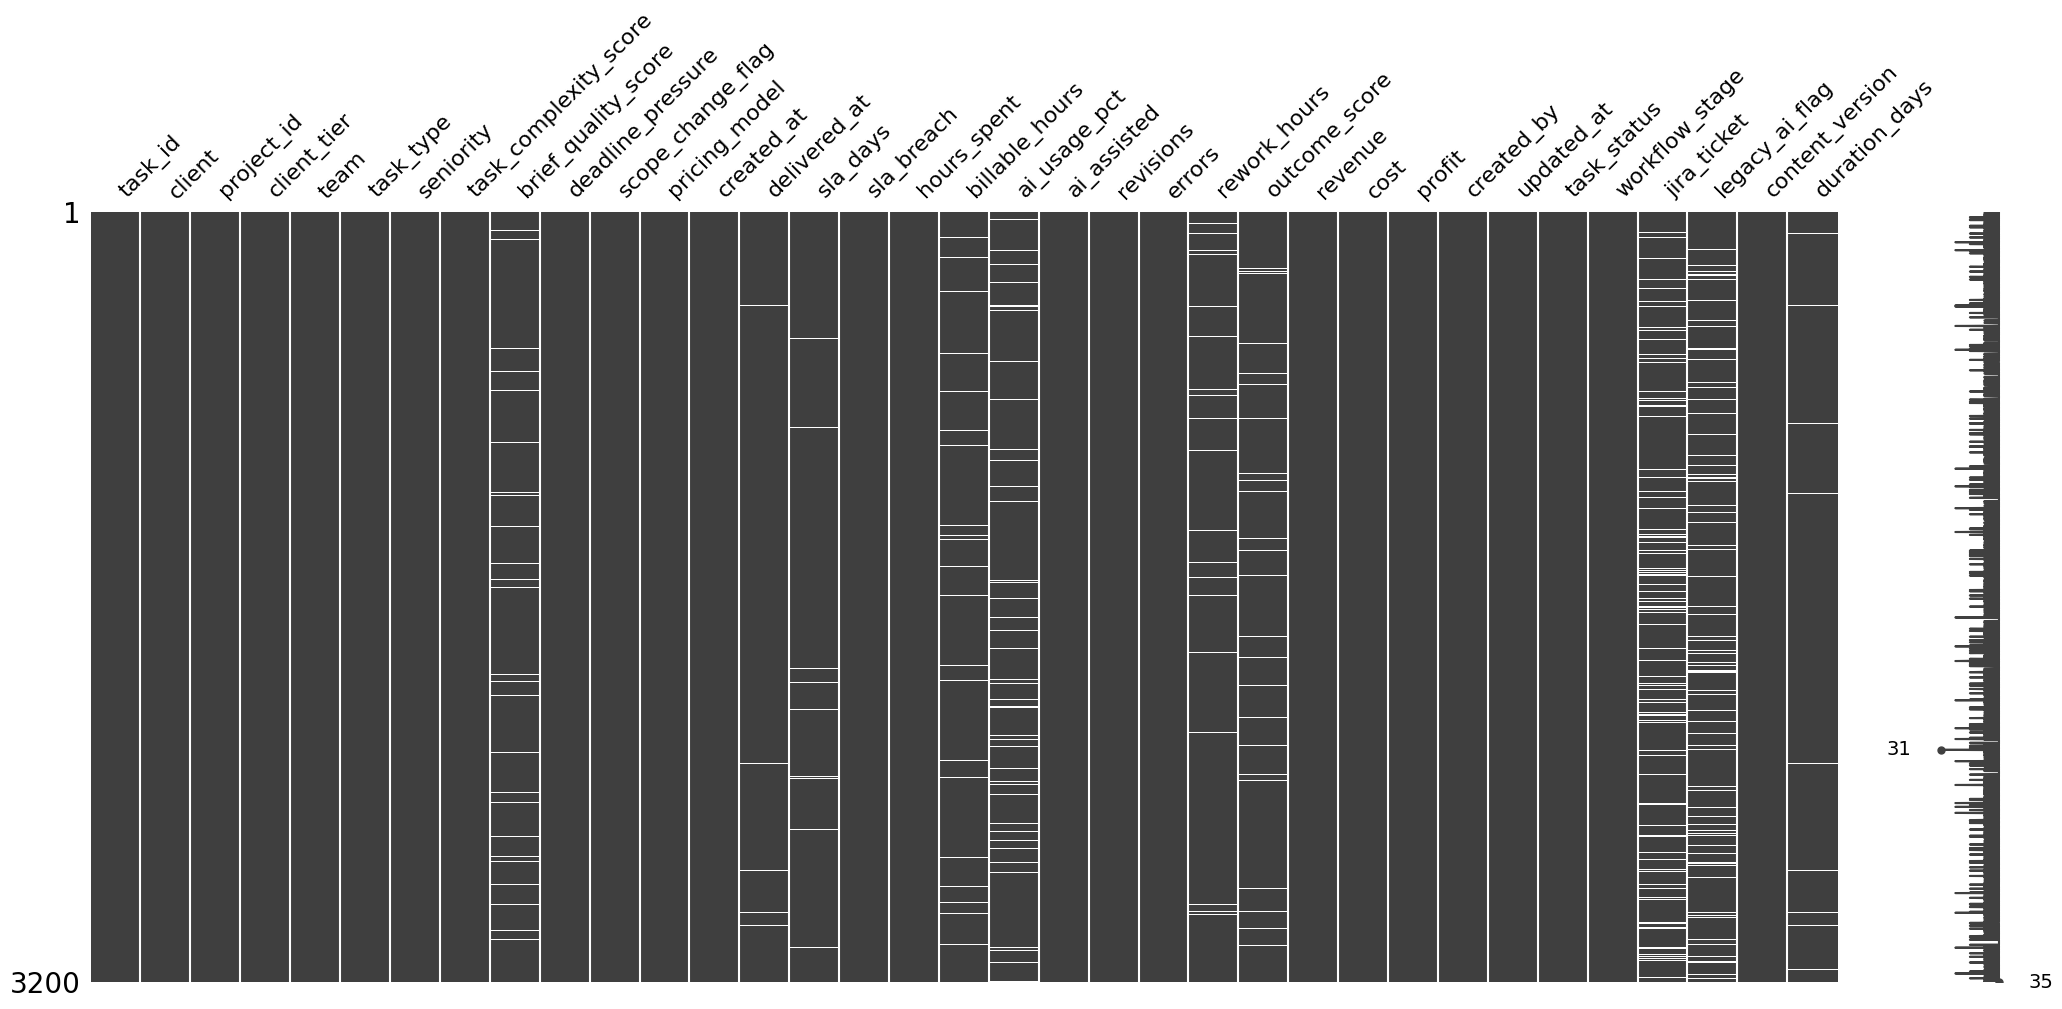

In [58]:
msno.matrix(df_productivity)

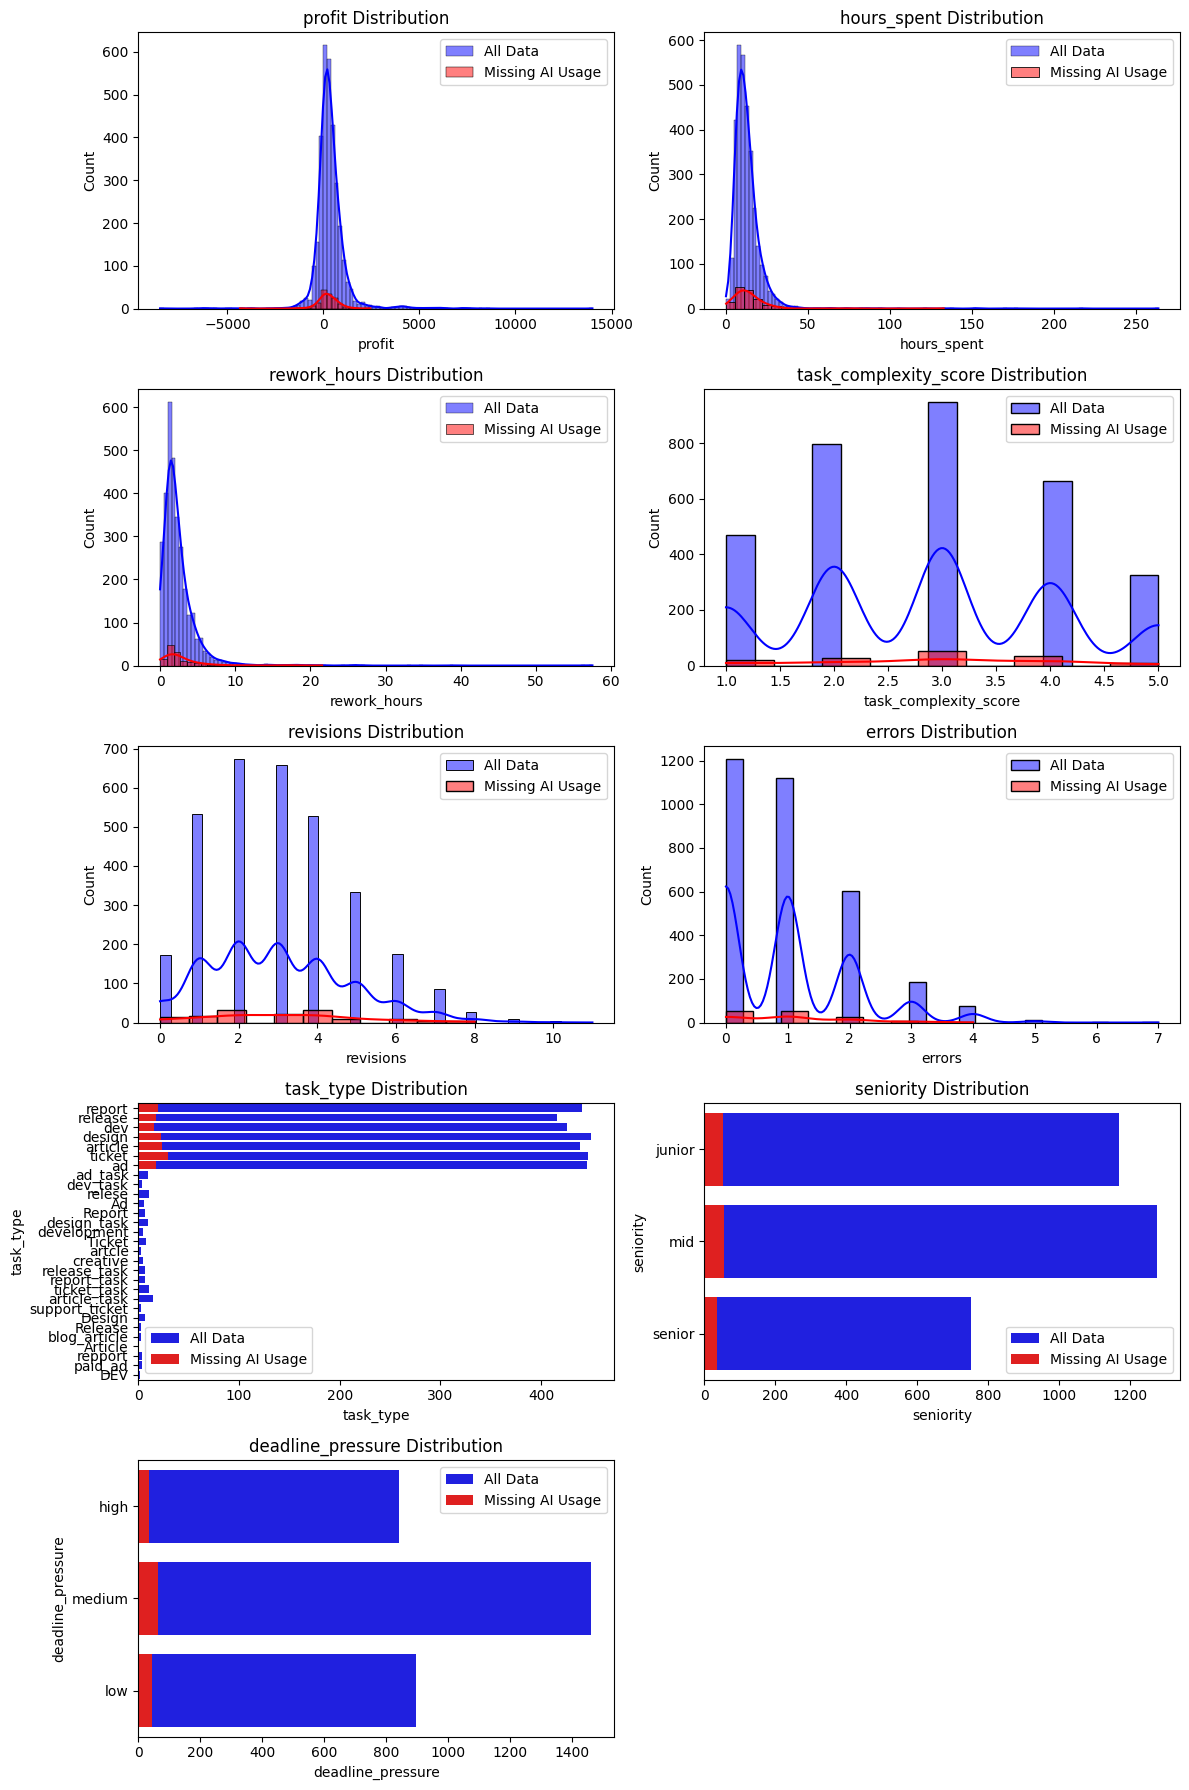

In [59]:
missing_ai_rows = df_productivity[df_productivity['ai_usage_pct'].isnull()]

columns = [
    'profit',
    'hours_spent',
    'rework_hours',
    'task_complexity_score',
    'revisions',
    'errors',
    'task_type',
    'seniority',
    'deadline_pressure'
]

fig, axes = plt.subplots(len(columns) // 2 + 1, 2, figsize=(12, 2 * len(columns)))
axes = axes.flatten()
for i, column in enumerate(columns):
    
    if column in df_productivity.select_dtypes(include=['int64', 'float64']).columns:
        sns.histplot(df_productivity[column], ax=axes[i], kde=True, color='blue', label='All Data')
        sns.histplot(missing_ai_rows[column], ax=axes[i], kde=True, color='red', label='Missing AI Usage')
    else:
        sns.countplot(data=df_productivity, y=column, ax=axes[i], color='blue', label='All Data')
        sns.countplot(data=missing_ai_rows, y=column, ax=axes[i], color='red', label='Missing AI Usage')
        
        axes[i].set_ylabel(column)
        axes[i].set_xlabel('Count')
    
    axes[i].set_title(f'{column} Distribution')
    axes[i].set_xlabel(column)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

#### Taking care of NaN values

In [60]:
df_productivity = df_productivity.drop(columns=['jira_ticket'], errors='ignore')

df_productivity['ai_usage_pct'] = df_productivity['ai_usage_pct'].fillna(
    df_productivity['ai_usage_pct'].median())

df_productivity['outcome_score'] = df_productivity['outcome_score'].fillna(
    df_productivity['outcome_score'].median())

df_productivity['brief_quality_score'] = df_productivity['brief_quality_score'].fillna(
    df_productivity['brief_quality_score'].median())

df_productivity['sla_days'] = df_productivity['sla_days'].fillna(
    df_productivity['sla_days'].median())

mask = df_productivity['billable_hours'].isna()
df_productivity.loc[mask, 'billable_hours'] = (
    df_productivity.loc[mask, 'hours_spent'] * 0.85)

df_productivity['rework_hours'] = df_productivity['rework_hours'].fillna(
    df_productivity['rework_hours'].median())

remaining = df_productivity.isnull().sum()
remaining = remaining[remaining > 0]

print("\nRemaining missing values:")
print(remaining)


Remaining missing values:
delivered_at       38
legacy_ai_flag    337
duration_days      52
dtype: int64


### Data Cleaning Summary (Missing Values)

Following the initial feature engineering, we directed our attention to analyzing and handling missing data across the dataset:

#### 1. Missing Value Analysis
We calculated the volume of missing values, observing that `legacy_ai_flag` (~10.5%) and `jira_ticket` (~10.3%) had the highest percentage of missingness. Other numerical features like `ai_usage_pct` (~4.5%) and `outcome_score` (~4.1%) also contained nulls. A missingno matrix was plotted to visually inspect the sparsity and ensure there were no critical monotone missing patterns.

#### 2. Visualizing Distributions
To determine robust imputation strategies, we plotted the exact distributions of task-oriented features (`profit`, `hours_spent`, `rework_hours`, `task_complexity_score`, etc.) for the subset of records where `ai_usage_pct` was missing. This confirmed the data was relatively uniform and allowed us to proceed with standard imputation techniques.

#### 3. Handling NaN Values (Imputation & Dropping)
To optimize the dataset for machine learning without introducing severe bias, the following treatments were applied to the missing records:
- **Dropped Column**: The `jira_ticket` column was dropped entirely. It functions solely as a unique text identifier, and given its high missing rate, it offers no predictive value for modeling.
- **Median Imputation**: For continuous and scoring metrics (`ai_usage_pct`, `outcome_score`, `brief_quality_score`, `sla_days`, `rework_hours`), we applied **median imputation** to fill the `NaN` values. Using the median ensures that the imputed data is robust and not skewed by extreme outliers.
- **Derived Imputation**: Missing values in `billable_hours` were filled using a logical heuristic based on recorded effort. Specifically, we set the missing billable hours to **85% of the `hours_spent`**, reflecting a realistic effective billing rate.

After this phase, the bulk of feature-level missing values were resolved, paving the way for outlier detection and handling.

In [61]:
df_productivity['scope_change_flag'] = df_productivity['scope_change_flag'].astype(bool)
df_productivity['sla_breach']        = df_productivity['sla_breach'].astype(bool)

# Verify
print(df_productivity[['scope_change_flag', 'sla_breach']].dtypes)
display(df_productivity["scope_change_flag"].value_counts().to_frame())
display(df_productivity["sla_breach"].value_counts().to_frame())


scope_change_flag    bool
sla_breach           bool
dtype: object


,count
scope_change_flag,
False,2757
True,443


,count
sla_breach,
False,1929
True,1271


In [62]:
# Re-define num_cols
num_cols = [col for col in df_productivity.select_dtypes(include=['int64', 'float64']).columns if col != 'legacy_ai_flag']

# We have to exclude the column "legacy_ai_flag" now because after we standardized it, ir counts as a numeric column
# even if it shouldn't.


#### Type Correction — Binary Flags
Two columns (`scope_change_flag` and `sla_breach`) are semantically boolean flags
but were loaded as integers. Converting them to `bool` ensures they are excluded
from numerical outlier analysis and treated correctly downstream.

#### Check for outliers

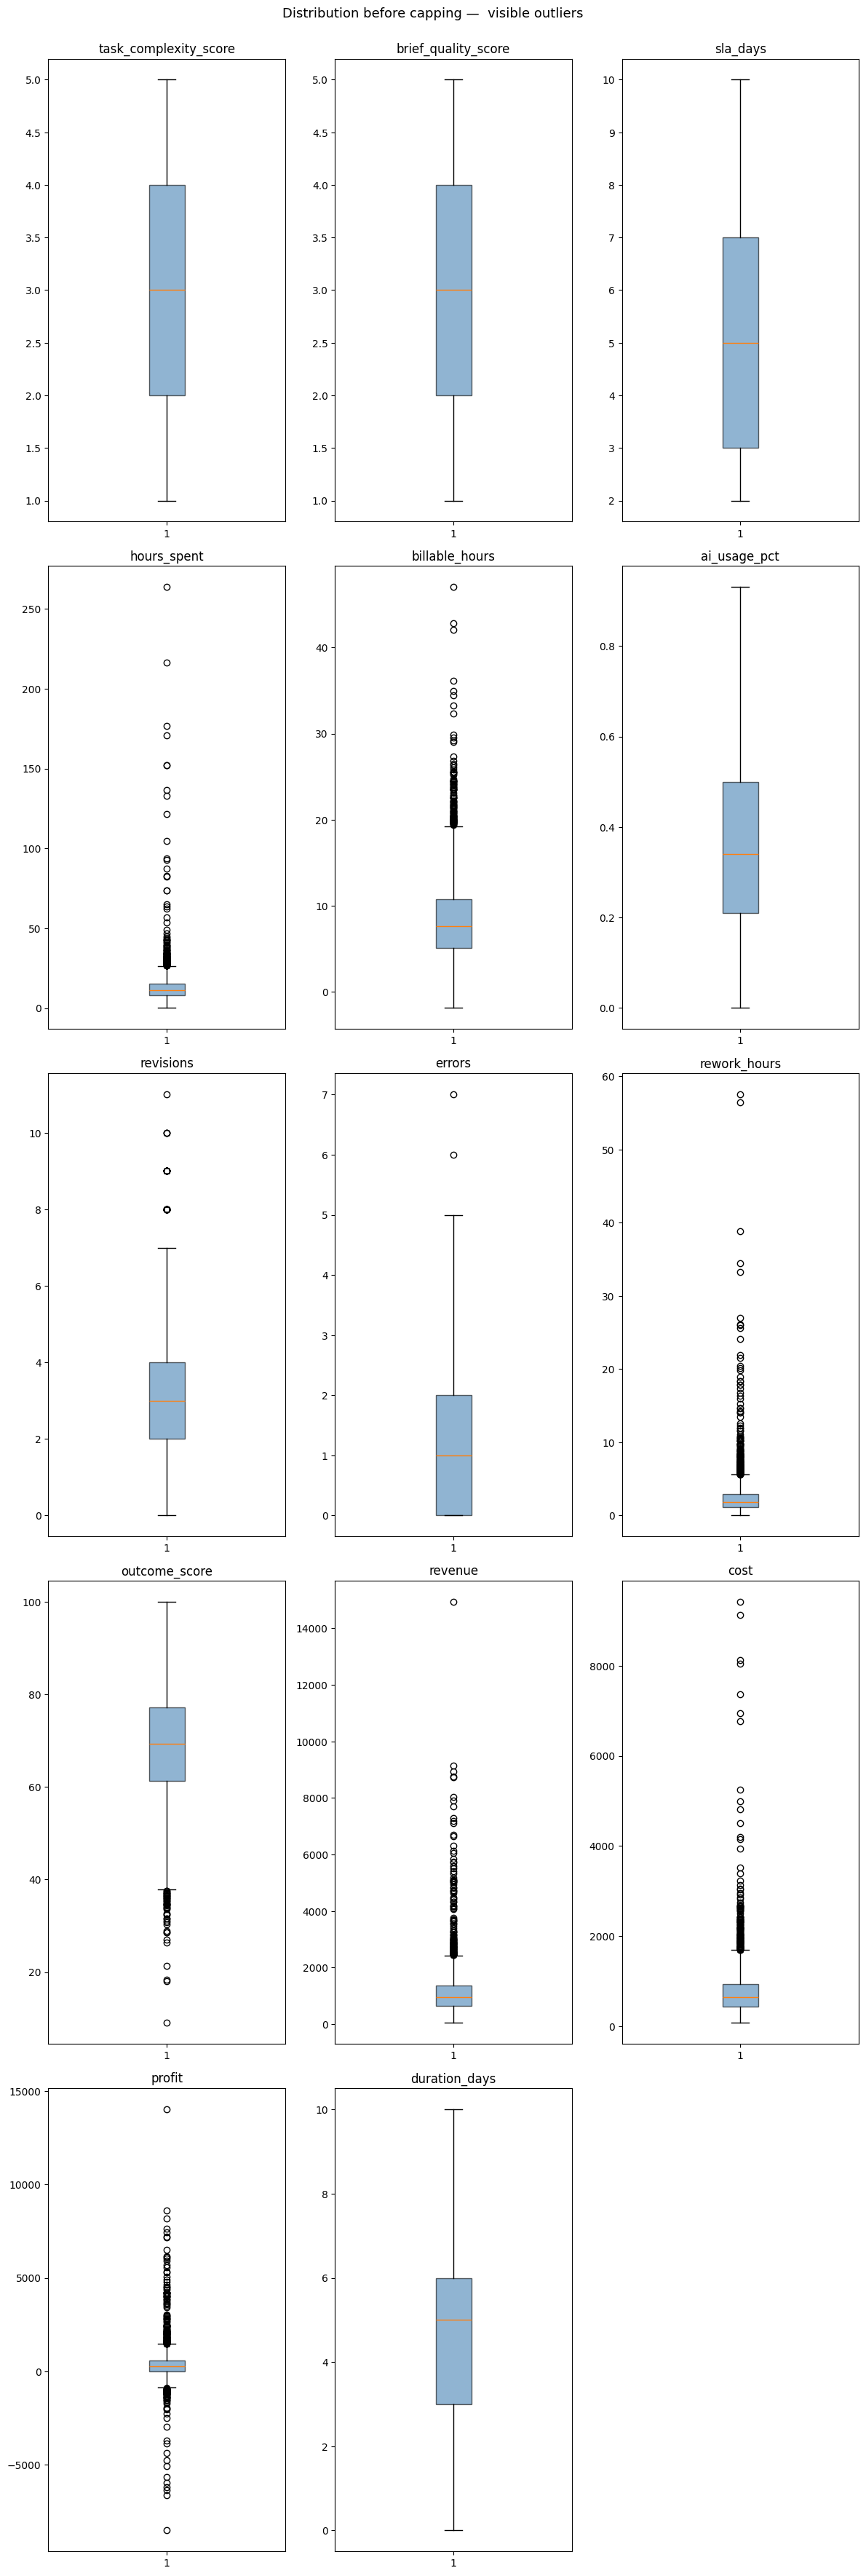

In [63]:
fig, axes = plt.subplots(len(num_cols) // 2 + 1, 3, figsize=(12, 4*len(num_cols)))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df_productivity[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
plt.suptitle('Distribution before capping —  visible outliers', fontsize=13, y = 1.0001)
plt.tight_layout()

In [64]:
outlier_summary = []

for col in num_cols:
    Q1 = df_productivity[col].quantile(0.25)
    Q3 = df_productivity[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate 3x IQR bounds
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    
    n_out = ((df_productivity[col] < lower) | (df_productivity[col] > upper)).sum()
    pct = (n_out / len(df_productivity)) * 100
    
    # Append the results as a new row
    outlier_summary.append({
        'Feature': col,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': n_out,
        '% Outliers': pct
    })

# Convert to DataFrame
df_outliers = pd.DataFrame(outlier_summary)

# Display with clean formatting (rounds numbers and adds % sign)
display(df_outliers.style.hide(axis='index').format({
    'Lower Bound': '{:.2f}',
    'Upper Bound': '{:.2f}',
    '% Outliers': '{:.1f}%'
}).set_caption("Extreme Outliers (3 × IQR)"))

Feature,Lower Bound,Upper Bound,Outlier Count,% Outliers
task_complexity_score,-4.00,10.00,0,0.0%
brief_quality_score,-4.00,10.00,0,0.0%
sla_days,-9.00,19.00,0,0.0%
hours_spent,-14.37,37.59,38,1.2%
billable_hours,-11.91,27.78,12,0.4%
ai_usage_pct,-0.66,1.37,0,0.0%
revisions,-4.00,10.00,1,0.0%
errors,-6.00,8.00,0,0.0%
rework_hours,-4.28,8.32,71,2.2%
outcome_score,13.81,124.78,1,0.0%


### Outlier Analysis Summary

After handling the missing values in the dataset, we turned our attention to identifying and treating extreme values in the numerical variables. The analysis was carried out in three stages.
#### 1. Visual Inspection via Boxplots
All 13 genuinely numerical columns were plotted as boxplots **before any transformation**, providing a first visual assessment of the distributional spread and the presence of extreme values.
#### Outlier Treatment — Decision not to cap
After visual inspection of the boxplots and IQR-based detection, we decided **not to apply winsorization** to any variable. The IQR × 3 rule flags statistically extreme values, but statistical extremity is not the same as an error. In this dataset:
- `hours_spent` reaches 263 hours: long tasks are real and analytically relevant. Capping them would systematically exclude the most complex tasks from the analysis, introducing selection bias.
- `revenue` reaches €14,927: large contracts are real business cases, not data entry errors. Removing them would bias the analysis toward average-sized tasks and underrepresent the high-margin segment.
- `rework_hours` reaches 57 hours: while high, this is plausible for tasks with severe quality issues, which are precisely the cases most relevant to our research question.
- `profit` ranges from €8,510 to +€14,006: the company confirmed that revenue and cost are estimated figures. This means the uncertainty is distributed across the entire dataset, not concentrated in the extremes. Capping the extremes while leaving the rest unchanged would be arbitrary.

For these reasons, we retain all observations as-is and rely on robust statistical methods downstream, specifically Spearman correlation (which is rank-based and less sensitive to extremes) and median-based imputation,rather than removing information from the dataset.

#### Correlation

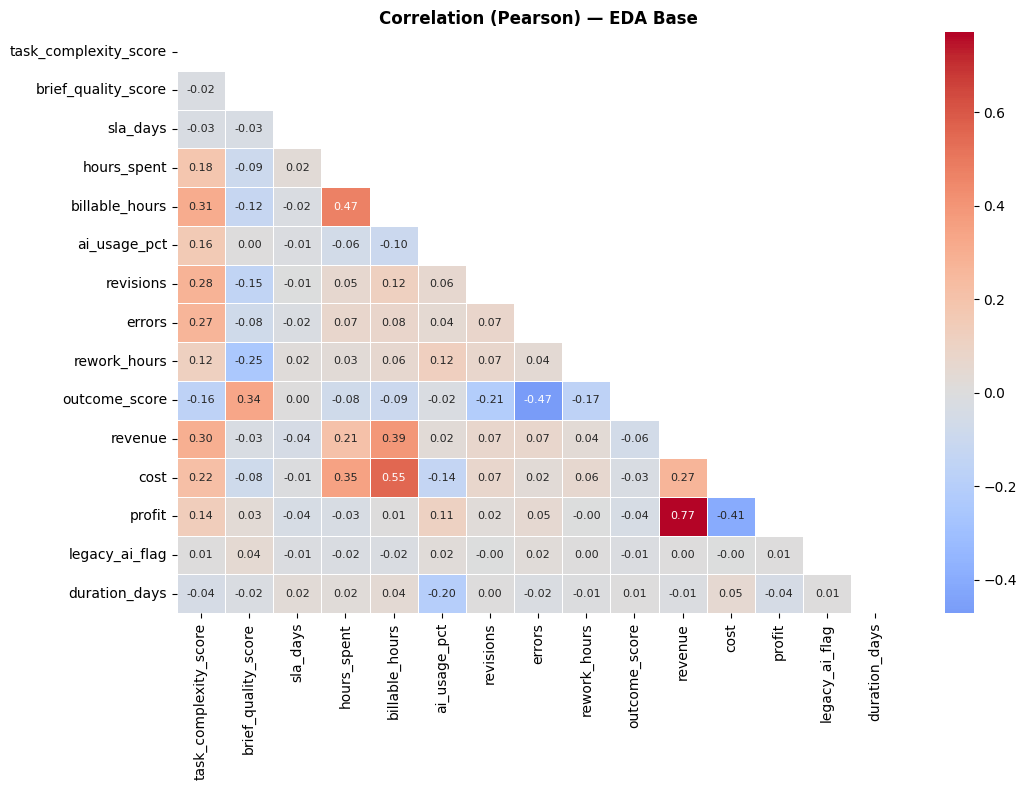

In [65]:
numeric = df_productivity.select_dtypes(include=[np.number])
exclude = ['scope_change_flag', 'sla_breach']
numeric = numeric.drop(columns=[c for c in exclude if c in numeric.columns])

corr = numeric.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8})

plt.title('Correlation (Pearson) — EDA Base', fontweight='bold')
plt.tight_layout()

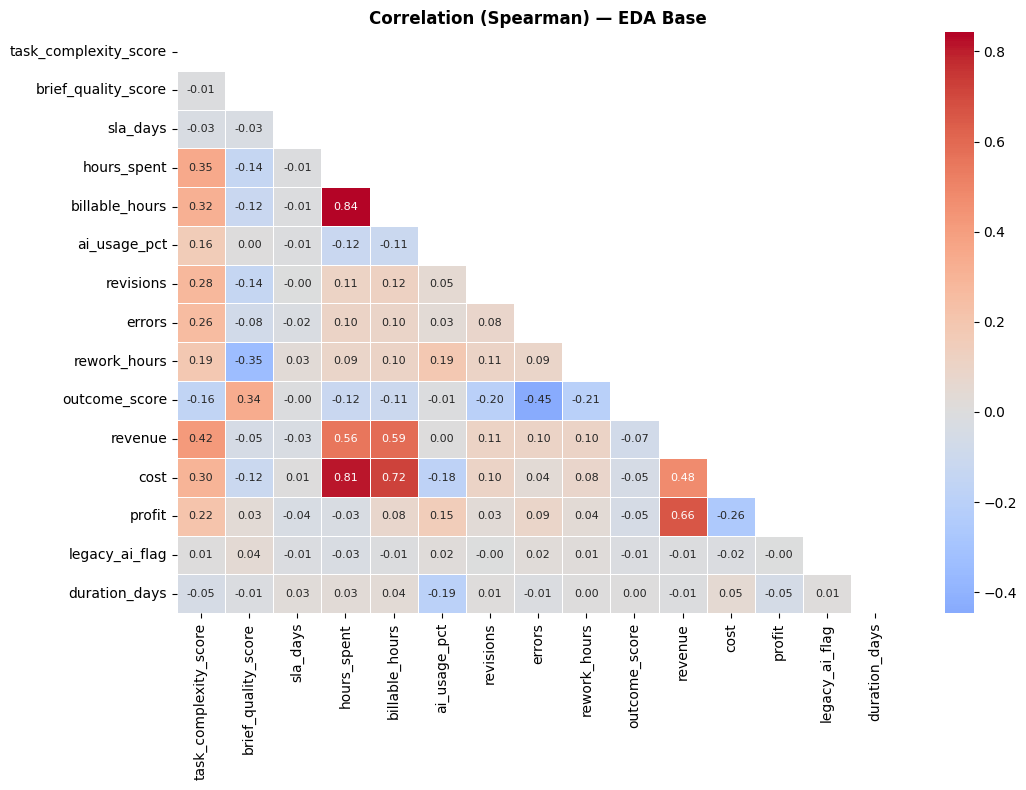

In [66]:
numeric = df_productivity.select_dtypes(include=[np.number])
exclude = ['scope_change_flag', 'sla_breach']
numeric = numeric.drop(columns=[c for c in exclude if c in numeric.columns])

corr = numeric.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8})

plt.title('Correlation (Spearman) — EDA Base', fontweight='bold')
plt.tight_layout()

### Correlation Analysis Summary

After cleaning and capping the numerical variables, we explored the linear and monotonic relationships between all 13 numerical features using two complementary methods.

#### 1. Variable Selection
As in the outlier section, `scope_change_flag` and `sla_breach` were excluded from the analysis because they are binary flags — computing a Pearson or Spearman coefficient for binary variables against continuous ones can be misleading without additional context. The remaining **13 numerical columns** were used.

#### 2. Pearson Correlation (Linear Relationships)
A lower-triangle heatmap of **Pearson coefficients** was produced to detect linear associations. The most notable findings are:

| Pair | Pearson r | Interpretation |
|------|-----------|----------------|
| `revenue` ↔ `profit` | **strong positive** | Profit scales closely with revenue (expected) |
| `revenue` ↔ `cost` | moderate positive | Higher revenue tasks also tend to cost more |
| `hours_spent` ↔ `billable_hours` | strong positive | Most worked hours are billable |
| `hours_spent` ↔ `rework_hours` | moderate positive | More hours → more rework (or vice-versa) |
| `rework_hours` ↔ `errors` | moderate positive | Error-prone tasks generate more rework |

Most other pairs showed weak or near-zero linear correlations, suggesting the dataset is not heavily collinear.

#### 3. Spearman Correlation (Monotonic Relationships)
A second heatmap was produced using **Spearman rank-order coefficients** to capture non-linear monotonic relationships and provide a robustness check. The Spearman results largely agreed with the Pearson findings, confirming that the associations detected are genuine and not artefacts of a specific distributional assumption.

## `Feature Engineering`

In [67]:
df_productivity.loc[
    df_productivity['billable_hours'] < 0, 'billable_hours'
] = np.nan

# 1
df_productivity['profit_margin'] = (
    df_productivity['profit'] / df_productivity['revenue'].replace(0, np.nan)
) * 100

df_productivity['ai_flag'] = (df_productivity['ai_usage_pct'] > 0).astype(int)

# 2
min_hours = 0.1
hours_safe = df_productivity['hours_spent'].clip(lower=min_hours)

df_productivity['rework_rate'] = df_productivity['rework_hours'] / hours_safe
df_productivity['error_rate']  = df_productivity['errors']       / hours_safe


# 3 

df_productivity['billable_ratio']   = df_productivity['billable_hours'] / hours_safe
df_productivity['revenue_per_hour'] = df_productivity['revenue']        / hours_safe
df_productivity['cost_per_hour']    = df_productivity['cost']           / hours_safe

# 4
df_productivity['ai_usage_sq'] = df_productivity['ai_usage_pct'] ** 2

# 5
median_cph = df_productivity['cost_per_hour'].median()
df_productivity['rework_cost_est']  = df_productivity['rework_hours'] * median_cph
df_productivity['hidden_cost_ratio'] = (
    df_productivity['rework_cost_est'] / df_productivity['cost'].replace(0, np.nan)
)
print(f"Median cost/hour used: €{median_cph:.2f}")

# 6
bins = [0, 0.20, 0.40, 0.60, 0.80, 1.01]
df_productivity['ai_bucket'] = pd.cut(
    df_productivity['ai_usage_pct'],
    bins=bins,
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'],
    include_lowest=True
)

# 7
df_productivity['is_high_ai'] = (df_productivity['ai_usage_pct'] >= 0.6).astype(int)

# 8
df_productivity['budget_bucket'] = pd.qcut(
    df_productivity['revenue'], q=2,
    labels=['low_budget', 'high_budget']
)
df_productivity['profit_bucket'] = pd.qcut(
    df_productivity['profit'], q=2,
    labels=['low_profit', 'high_profit']
)
df_productivity['complexity_bucket'] = pd.qcut(
    df_productivity['task_complexity_score'], q=3,
    labels=['low', 'medium', 'high']
)

# 9
df_productivity['duration_days'] = (
    df_productivity['delivered_at'] - df_productivity['created_at']
).dt.days

neg = (df_productivity['duration_days'] < 0).sum()
if neg > 0:
    df_productivity.loc[df_productivity['duration_days'] < 0, 'duration_days'] = np.nan
print(f"Negative durations fixed: {neg}")

# 10 
def cap_iqr(series, k=3):
    q1    = series.quantile(0.25)
    q3    = series.quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    n     = ((series < lower) | (series > upper)).sum()
    return series.clip(lower, upper), n

cap_cols = ['rework_rate', 'error_rate', 'billable_ratio',
            'revenue_per_hour', 'cost_per_hour', 'hidden_cost_ratio', 'profit_margin' ]

print("\nCapping (IQR x 3):\n")
for col in cap_cols:
    df_productivity[col], n = cap_iqr(df_productivity[col])
    print(f"  {col:<25} {n} valori cappati")

Median cost/hour used: €58.07
Negative durations fixed: 14

Capping (IQR x 3):

  rework_rate               91 valori cappati
  error_rate                27 valori cappati
  billable_ratio            18 valori cappati
  revenue_per_hour          104 valori cappati
  cost_per_hour             43 valori cappati
  hidden_cost_ratio         82 valori cappati
  profit_margin             67 valori cappati
